# ARoF DPD-MP

In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado"
file_path    = project_path + r"\DPD"
sys.path.append(project_path)

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal           import welch, firwin, hilbert
from scipy.constants        import pi
from tqdm.notebook          import tqdm
from tabulate               import tabulate

from optic.comm.modulation  import modulateGray
from optic.models.channels  import linearFiberChannel
from optic.models.devices   import mzm, photodiode
from optic.comm.metrics     import fastBERcalc, theoryBER, calcEVM
from optic.dsp.core         import pnorm, signal_power, upsample, pulseShape, firFilter, decimate, finddelay
from optic.utils            import parameters, dBm2W
from optic.comm.ofdm        import modulateOFDM, demodulateOFDM
from optic_private.dsp.core import calcACLR

from DPD_utils.MP_tools     import powerAmplifier, MP_filter, LS_solver, MP_training, calcSNR_per_carrier

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [24]:
# Parâmetros de modulação
modOrder = 64                          # Ordem da modulação
modType  = 'qam'                       # Tipo de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 64                               # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                  # Tam. da FFT
paramOFDM.Np   = 64                    # Núm. de subportadoras piloto
paramOFDM.G    = 32                    # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft-1, paramOFDM.Np, dtype=np.int64) # Pilot subcarriers
Ns = paramOFDM.Nfft - paramOFDM.Np     # Núm. de subportadoras de informação

Rs = Rb / ( Ns/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
batchSize = 1000//(int(paramOFDM.Nfft/128))
bits = np.random.randint(2, size = batchSize * Ns * int(np.log2(modOrder) ) )

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [25]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [26]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ns}'],
         ['Num. port. piloto', 'Np', f'{paramOFDM.Np}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 58.67 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.92 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [27]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi/2
paramMZM.Pin_OF = 15

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 30
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 10e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

#### 2.1 Sinal RF

In [28]:
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF = np.sqrt(dBm2W(paramRF.Pin_RF))*pnorm(sigTx_RF)

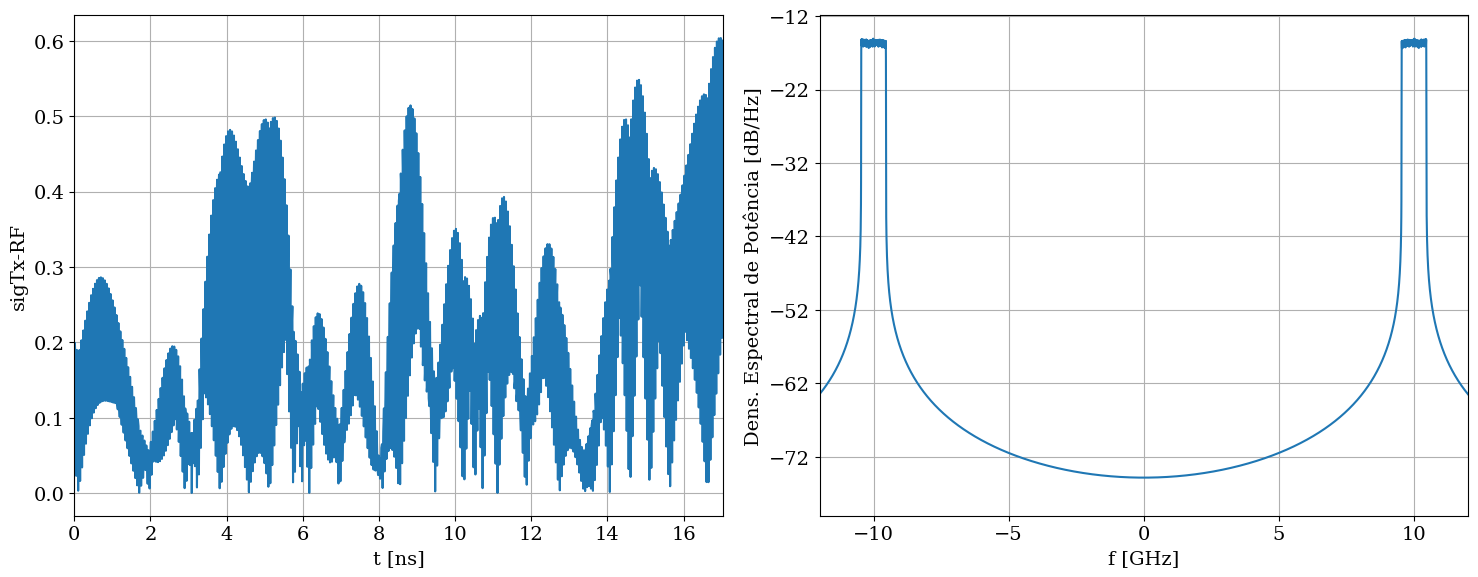

In [29]:

indx = np.arange(0, 1000)

fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(sigTx_RF[indx]))
axs[1].psd(sigTx_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("sigTx-RF")
axs[0].grid()

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-80)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.2 Sinal óptico

In [30]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

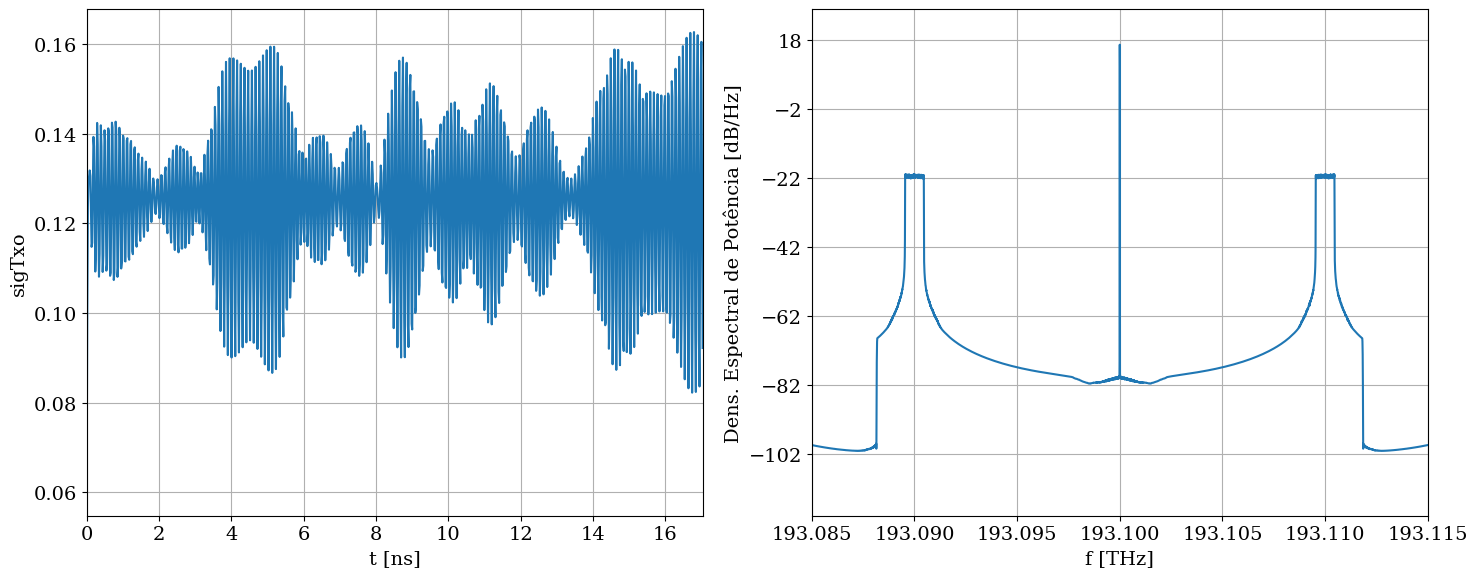

In [31]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(sigTxo[indx]))
axs[1].psd(np.abs(sigTxo)**2, Fs = Fs/1e12, Fc = paramChannel.Fc/1e12, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("sigTxo")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-0.015 + paramChannel.Fc/1e12, 0.015 + paramChannel.Fc/1e12)
axs[1].set_ylim(-120)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.3 Sinal elétrico (fotocorrente)

In [32]:
I_Rx = photodiode(sigRxo, paramPD)
I_Rx = pnorm(I_Rx)
I_Rx -= I_Rx.mean()

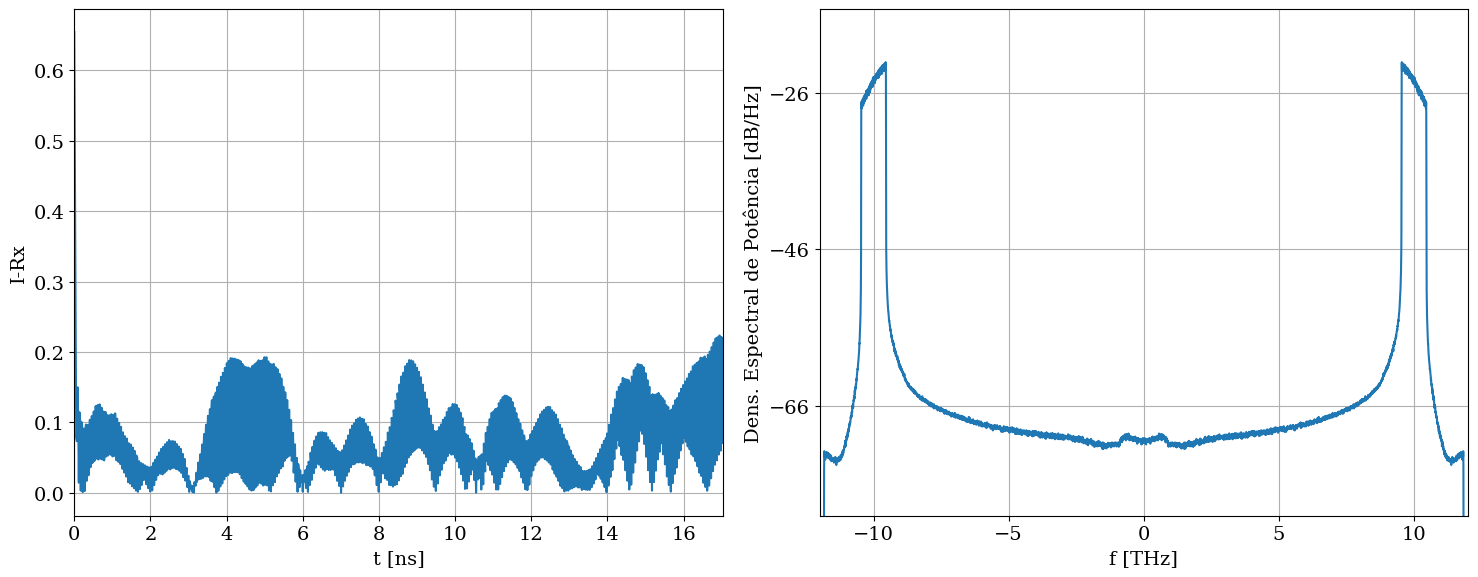

In [33]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(I_Rx[indx]))
axs[1].psd(I_Rx, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-Rx")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-80)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.4 Sinal elétrico pós-FPF

In [34]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

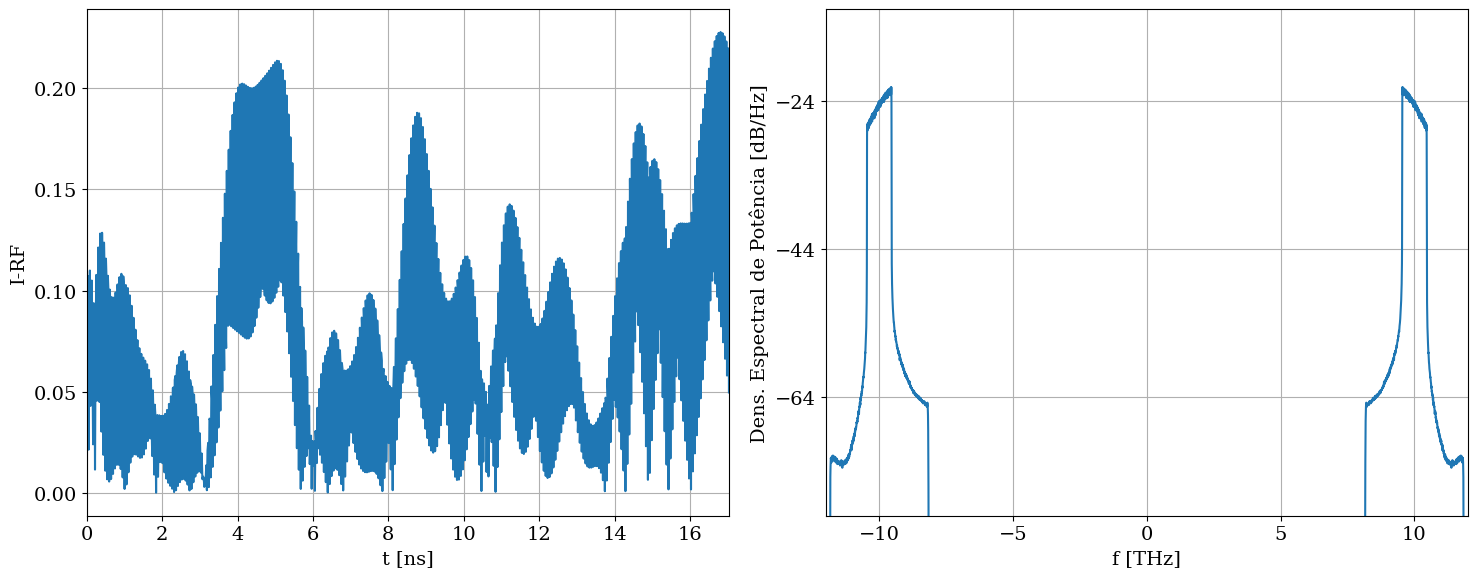

In [35]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(I_RF[indx]))
axs[1].psd(I_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-RF")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-80)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.5 Sinal elétrico pós-PA

In [36]:
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx = np.sqrt(dBm2W(paramRF.Pin_PA))*pnorm(sigRx)
sigRx = powerAmplifier(sigRx)

sigRx_PA = sigRx.copy()

numtaps = 4096
hlp = firwin(numtaps, Rs/1.5, fs = Fs)
sigRx = firFilter(hlp, sigRx)

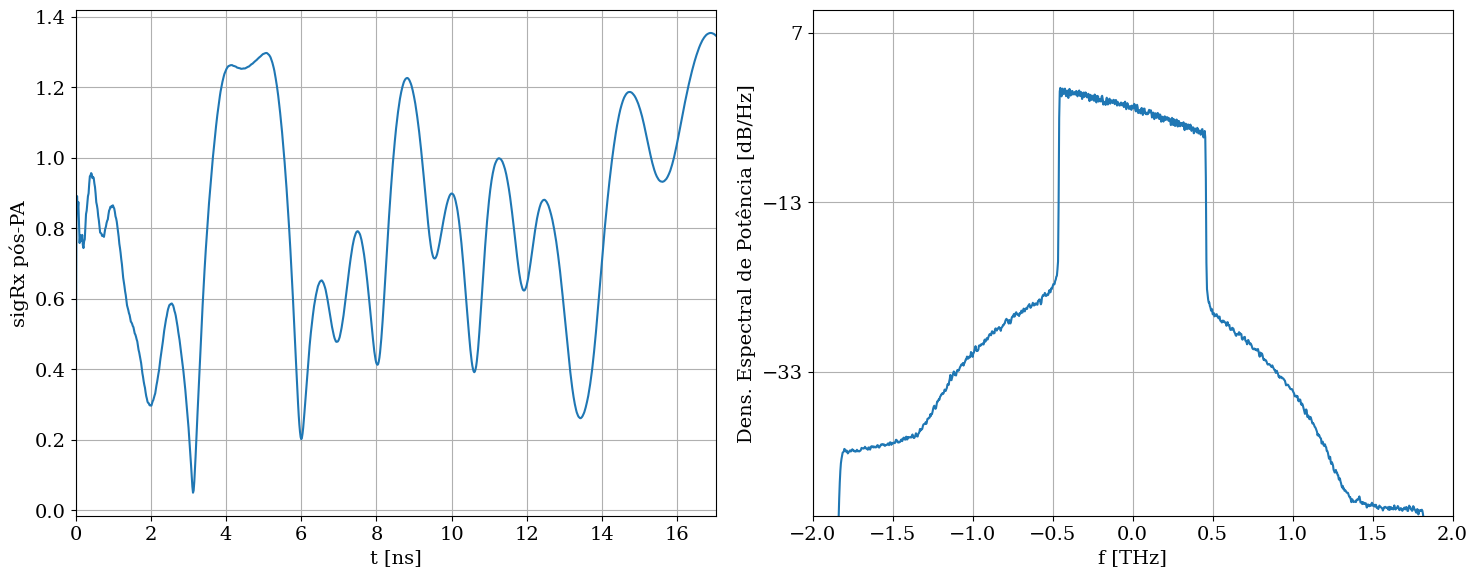

In [37]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(sigRx_PA[indx]))
axs[1].psd(sigRx_PA, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("sigRx pós-PA")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-50)
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [38]:
delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

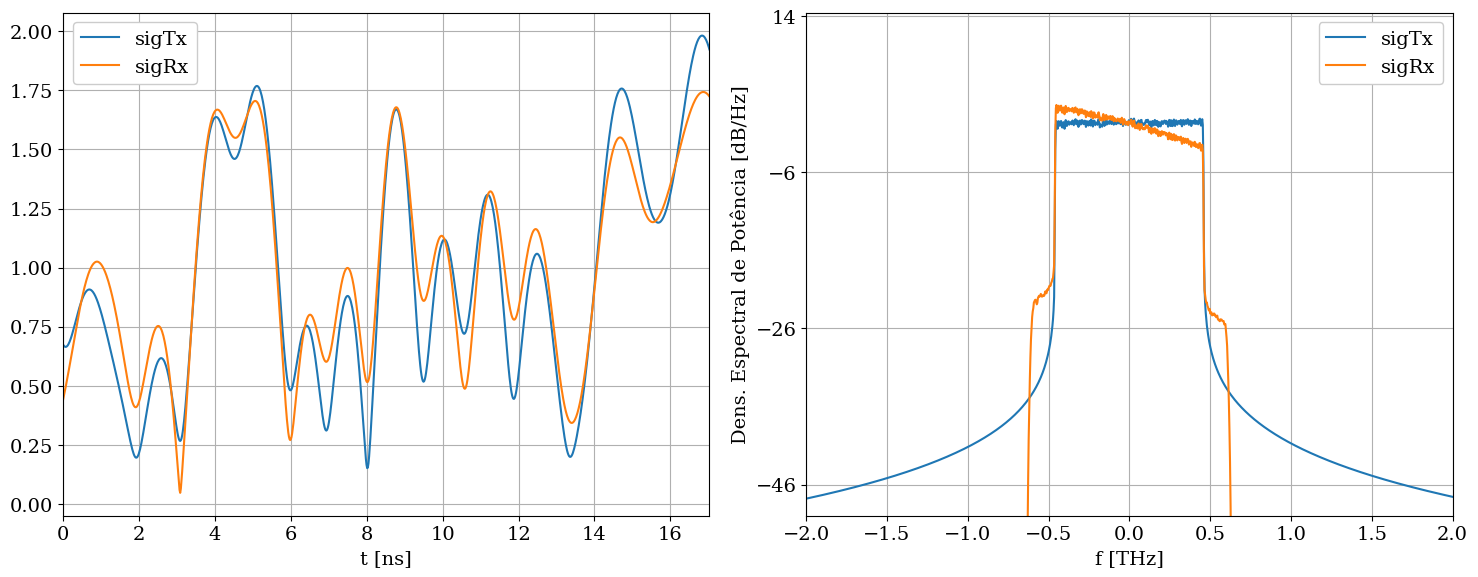

In [39]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigTx)[indx]), label = "sigTx")
axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigRx)[indx]), label = "sigRx")

axs[1].psd(pnorm(sigTx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "sigTx")
axs[1].psd(pnorm(sigRx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "sigRx")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1)

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1)

plt.tight_layout()
plt.show()

#### 2.6 Performance

In [40]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00802 
SNR = 20.474 dB


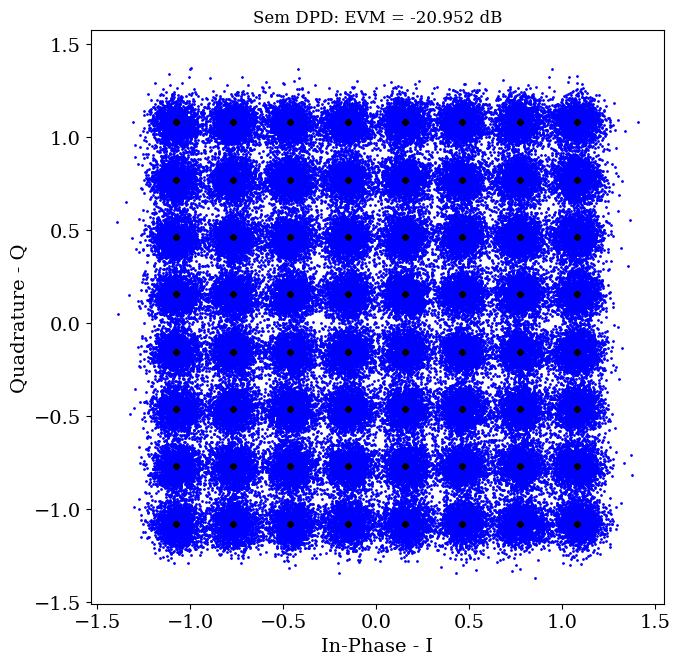

In [41]:
discard = 500
index = np.arange(discard, symbTx.size - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx, modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real, symbRx.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_title(f"Sem DPD: EVM = {EVM[0]:.3f} dB", fontsize = 12)
axs.set_ylabel("Quadrature - Q")
axs.set_xlabel("In-Phase - I")
plt.axis("square")
plt.tight_layout()

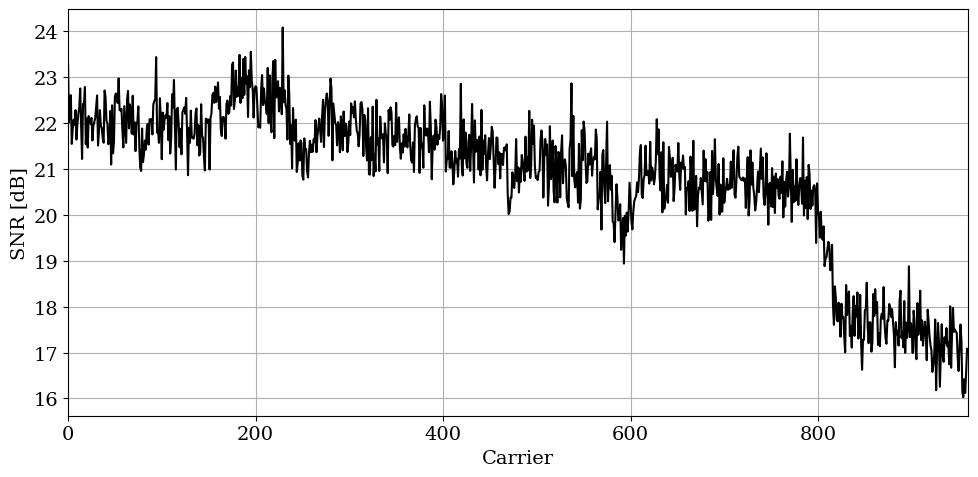

In [45]:
SNR_per_carrier = calcSNR_per_carrier(symbTx, symbRx, Ns)

fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(SNR_per_carrier, color = "k")
axs.set_xlim(0, Ns)
axs.set_ylabel("SNR [dB]")
axs.set_xlabel("Carrier")
axs.grid()
plt.tight_layout()

### 3 Identificação do canal

In [46]:
SpS_mp = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_mp

hlp = firwin(numtaps, SpS_mp*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec)
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec)

sigRef = pnorm(sigRef).ravel()
sigIn  = pnorm(sigIn).ravel()

In [47]:
delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

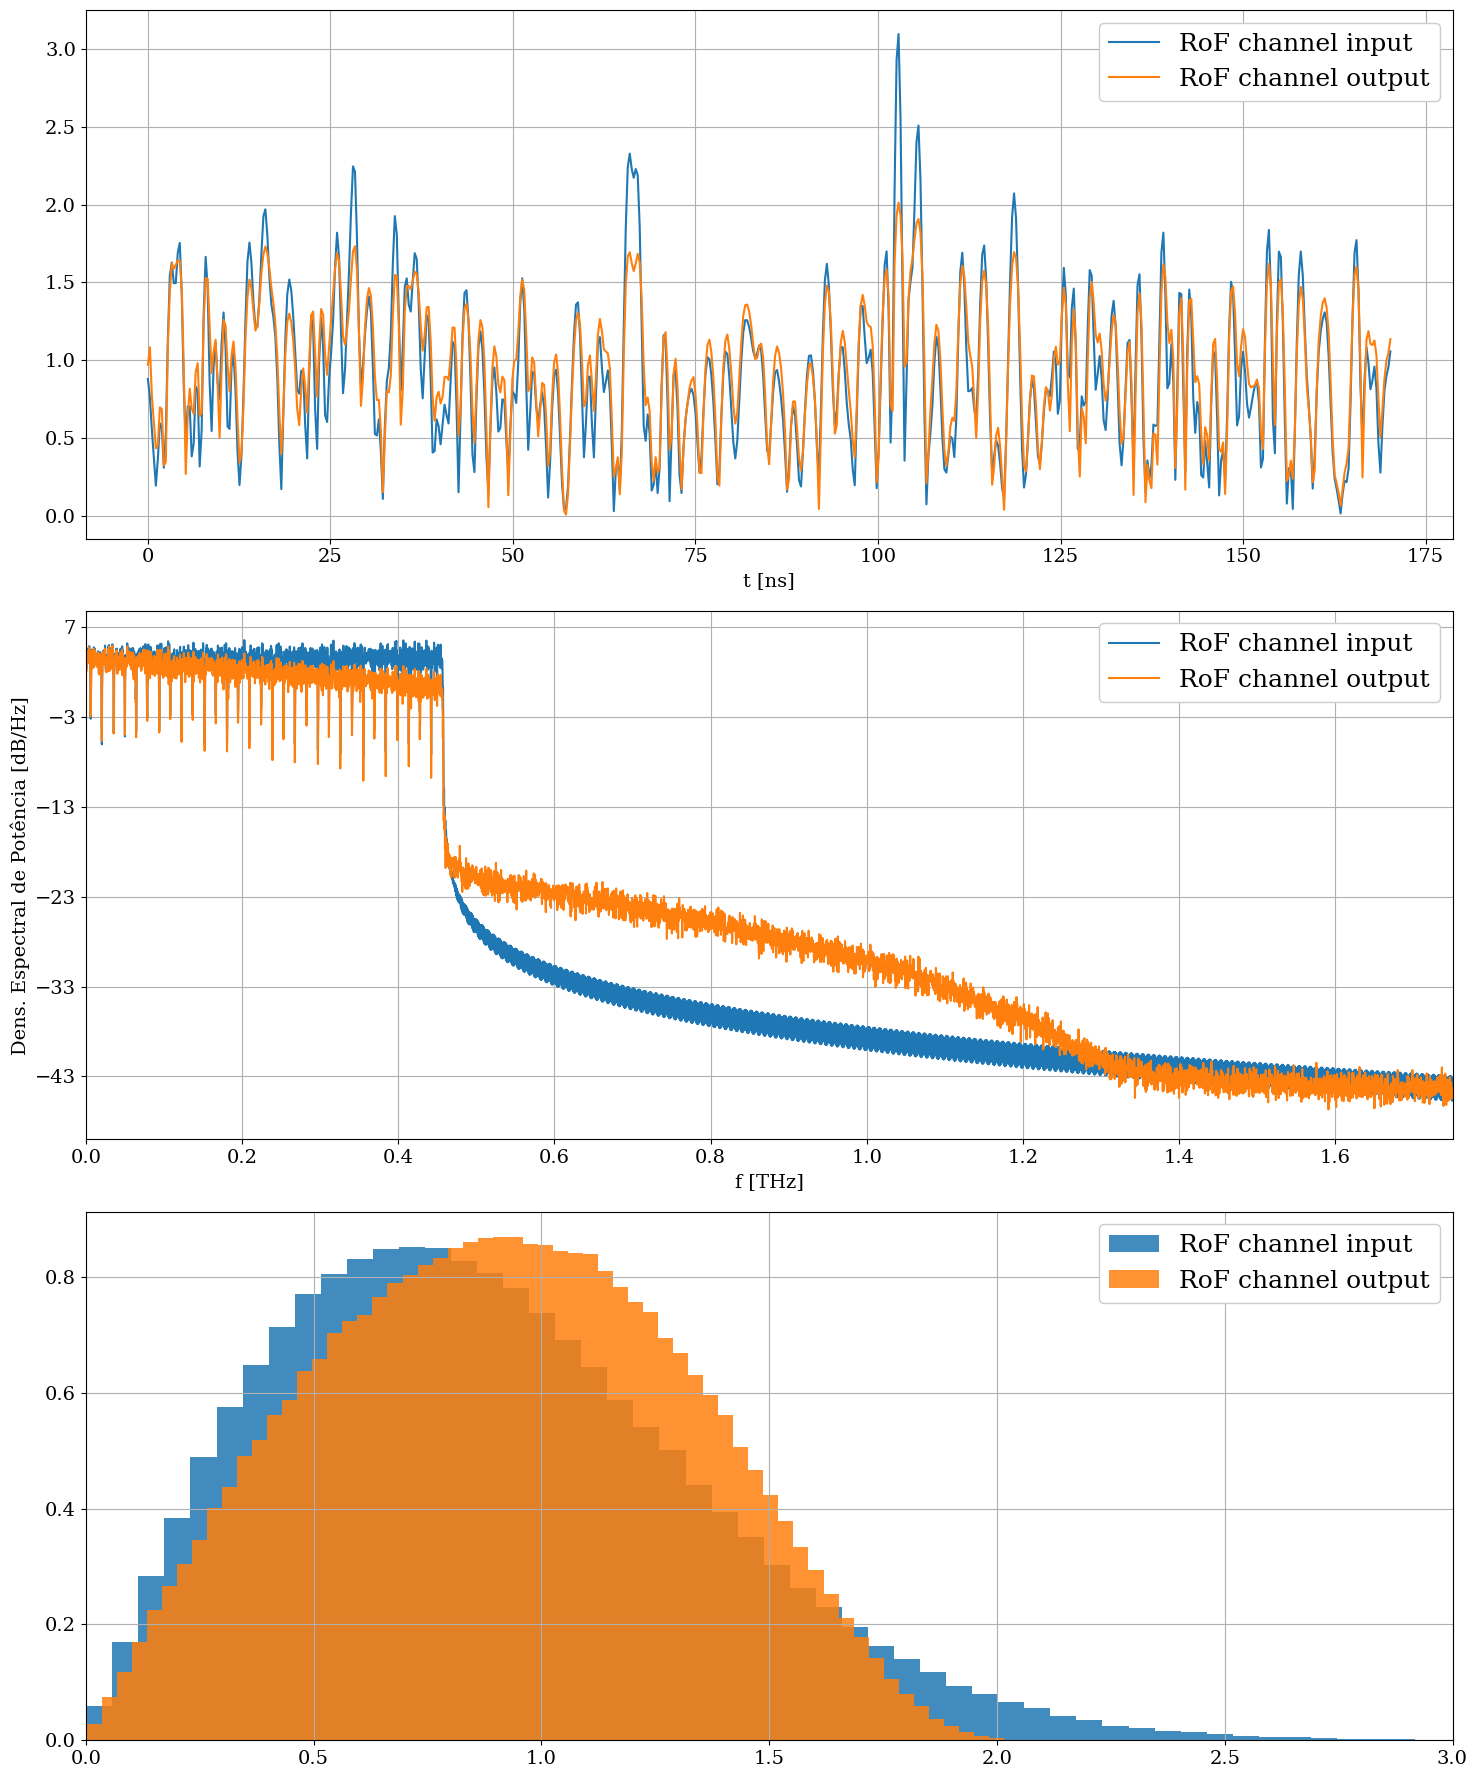

In [48]:
indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), label = "RoF channel input")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]), label = "RoF channel output")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'onesided', label = "RoF channel input")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'onesided', label = "RoF channel output")

axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(0, 1.75)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

In [143]:
K_sweep = np.arange(1, 8)
L_sweep = np.arange(1, 8)

MSE_matrix = np.zeros((K_sweep.size, L_sweep.size))
N = 10000

for i, kk in enumerate(K_sweep):
    for j, ll in enumerate(L_sweep):
        a_kl = LS_solver(sigRef[0:N], sigIn[0:N], kk, ll)
        sig_mp = MP_filter(sigRef, a_kl)
        MSE_matrix[i,j] = 10*np.log10(np.mean(np.abs(sig_mp - sigIn)**2))

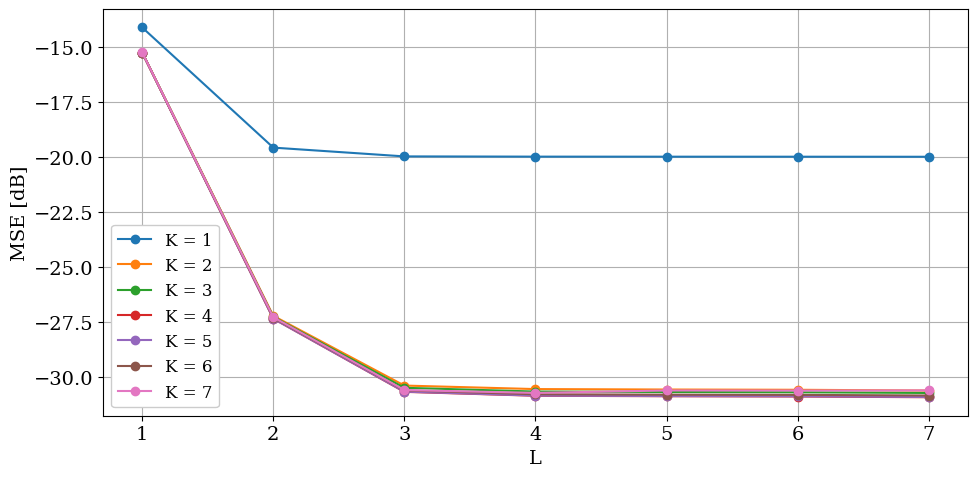

In [144]:

plt.figure(figsize = (10, 5))

for i, kk in enumerate(K_sweep):
    plt.plot(L_sweep, MSE_matrix[i,:], "-o", label = f"K = {kk}")

plt.xticks(L_sweep)
plt.legend(fontsize = 12, framealpha = 1)
plt.ylabel("MSE [dB]")
plt.xlabel("L")
plt.grid()
plt.tight_layout()

In [ ]:
P = 3
M = 8

K = 3
L = 8

N = 50000

a_kl  = LS_solver(sigRef[0:N], sigIn[0:N], K, L)
sig_mp = MP_filter(sigRef, a_kl)
sig_mp = pnorm(sig_mp)

In [54]:
sig_mp = MP_filter(sigRef, a_kl)
sig_mp = pnorm(sig_mp)

MSE = -31.176 dB


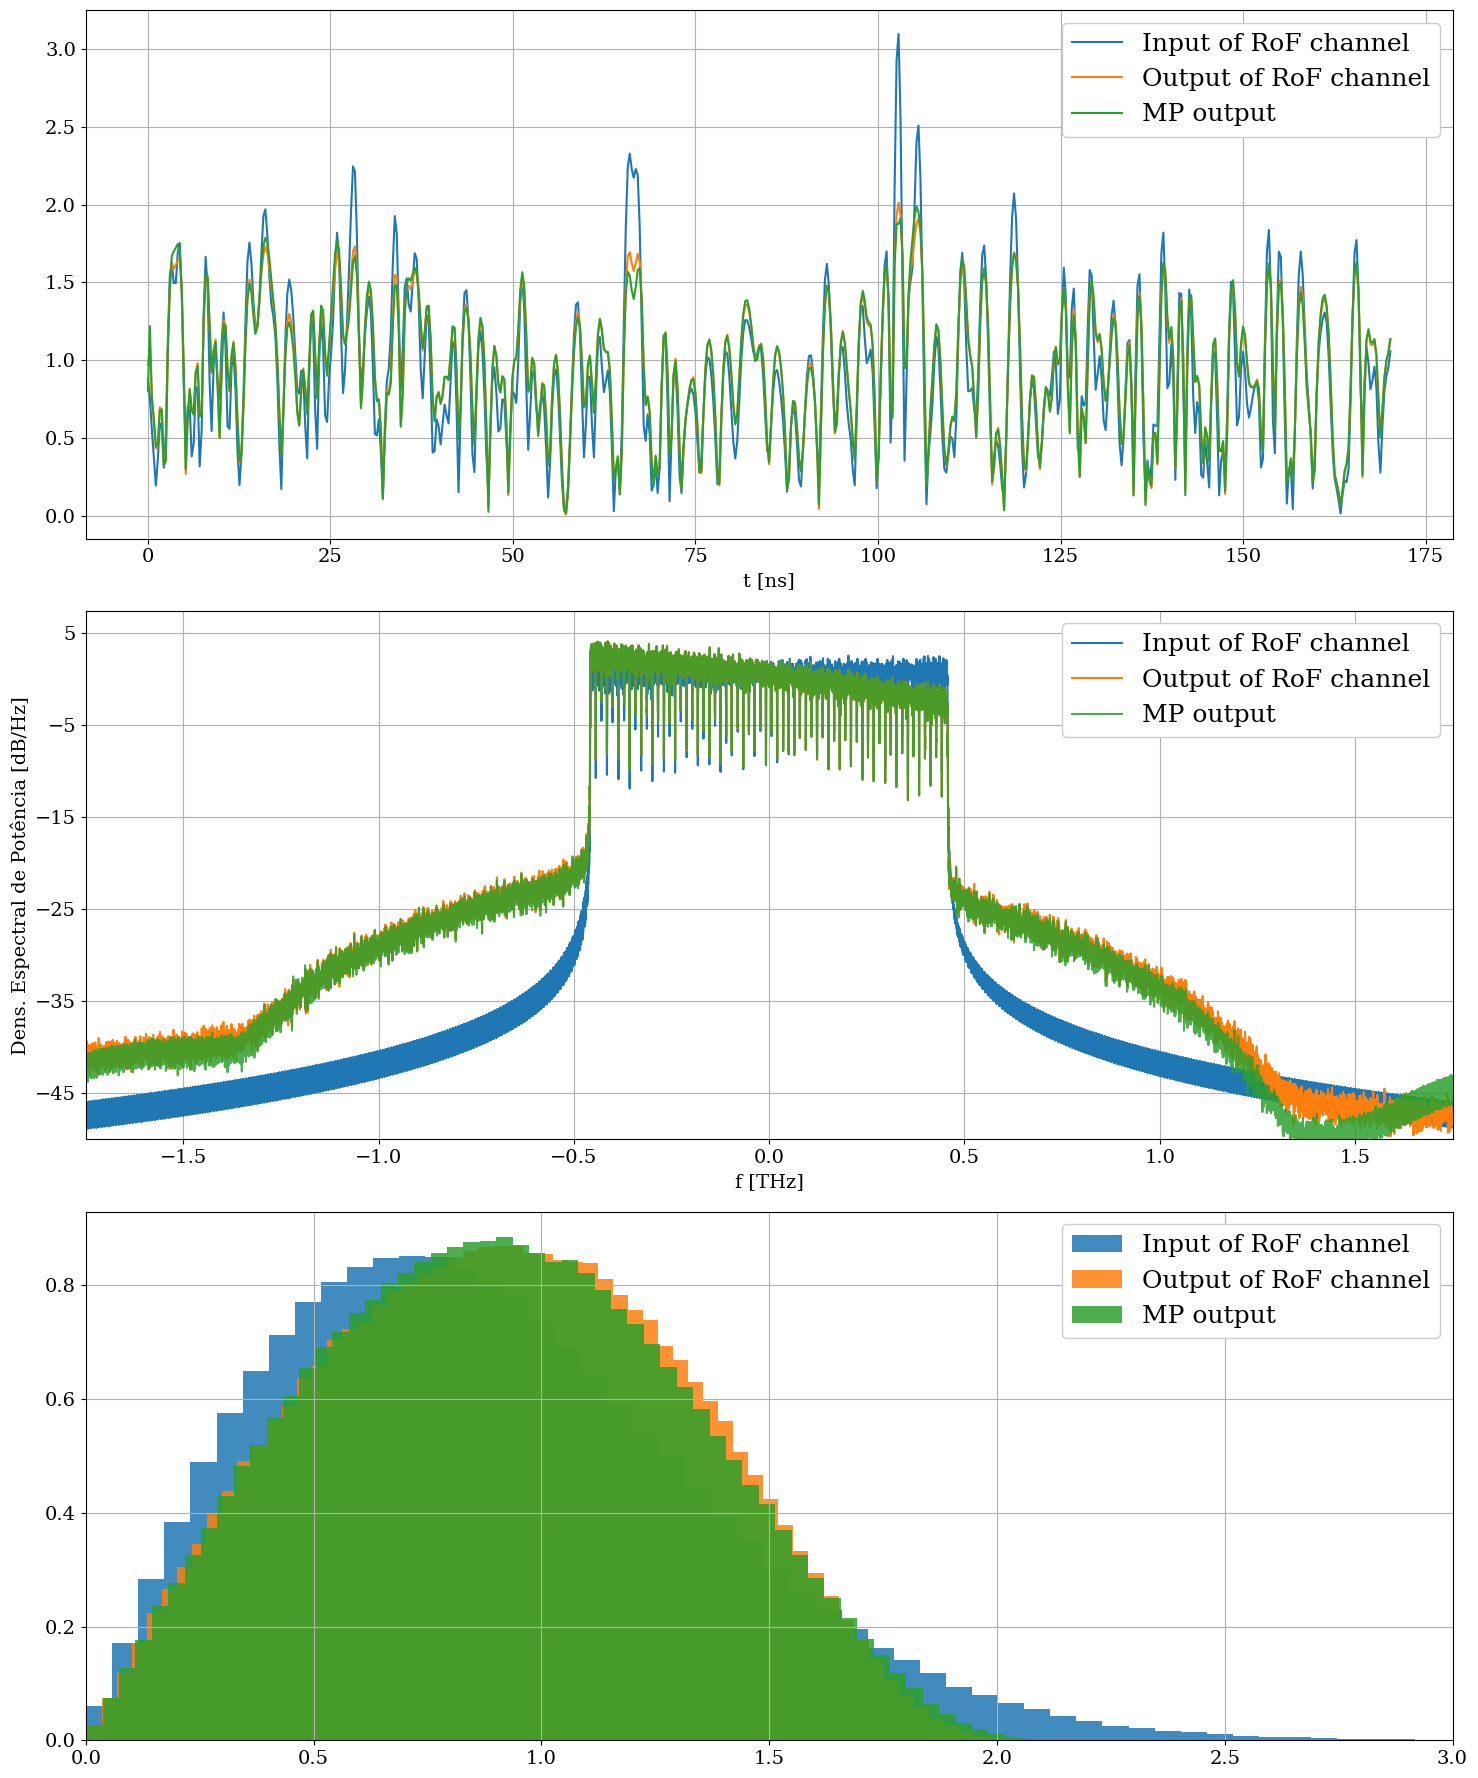

In [55]:
indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigIn)**2)):.3f} dB")

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]), label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), label = "MP output")

axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Output of RoF channel")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "MP output", alpha = 0.85)
axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.75, 1.75)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [62]:
#
paramTrain = parameters()
paramTrain.M = M
paramTrain.P = P

paramTrain.N = 20000
paramTrain.numIter = 5

paramTrain.mu  = 1e-3
paramTrain.lbd = 0.9999
paramTrain.S   = 5*np.eye(paramTrain.P*paramTrain.M, dtype = complex)*1e-2

paramTrain.alg = "RLS"
paramTrain.a_kl = a_kl
paramTrain.directLearn = False

paramTrain.pgrsBar    = True
paramTrain.storeCoeff = False

w_ila, errSq = MP_training(sigRef, paramTrain, sigIn)

  0%|          | 0/5 [00:00<?, ?it/s]

In [63]:
sig_mp = MP_filter(sigIn, np.conj(w_ila).reshape( (P, M) ) )

MSE = -32.954 dB


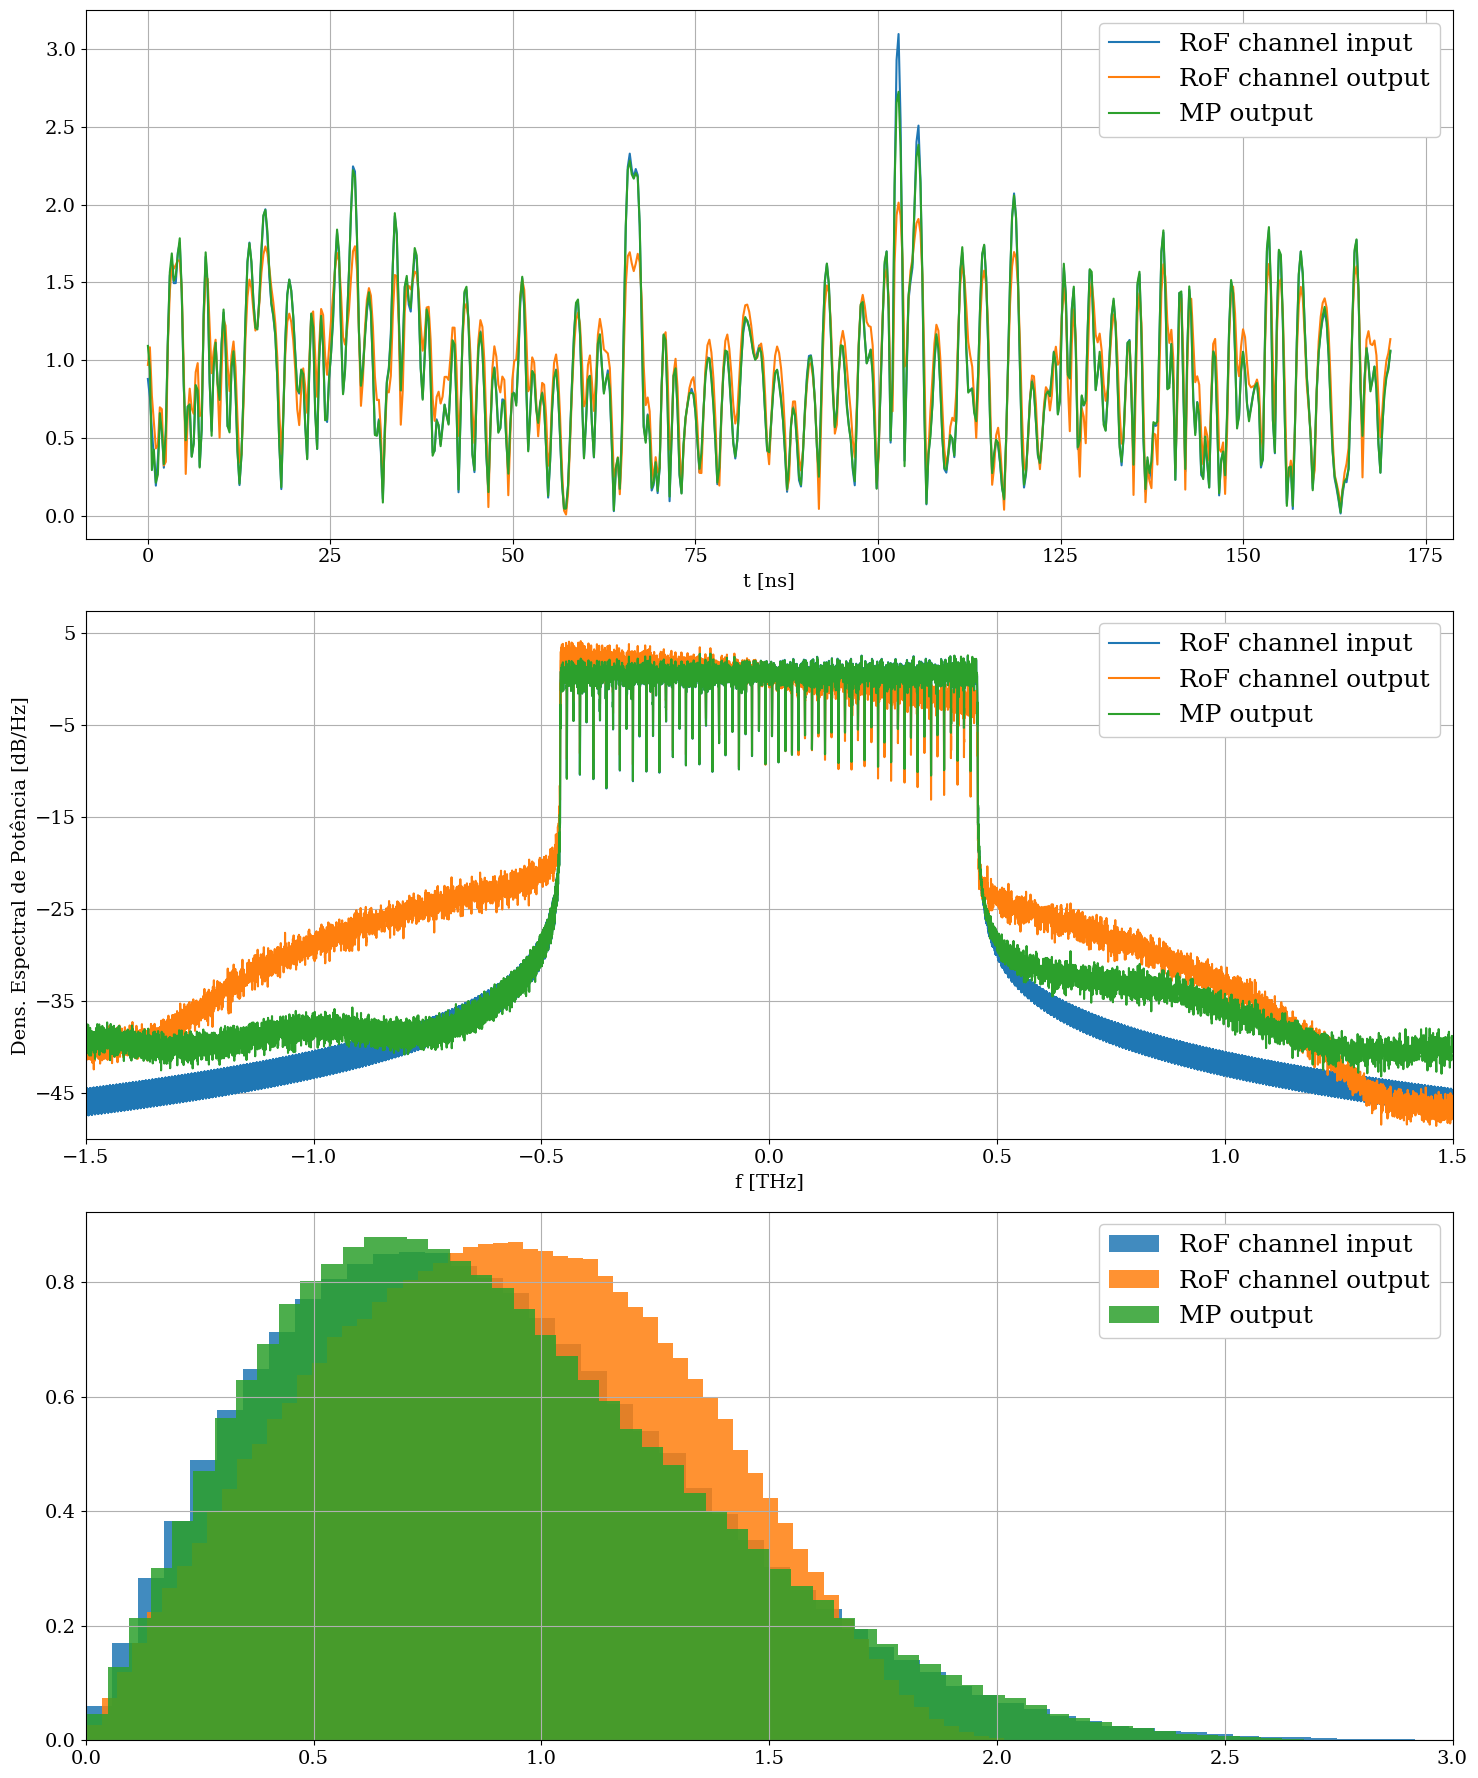

In [64]:
print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigRef)**2)):.3f} dB")

indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), label = "RoF channel input")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]), label = "RoF channel output")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), label = "MP output")
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
#axs[0].set_ylim(0, 3)
axs[0].grid()

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel input")
axs[1].psd(sigIn,  Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel output")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "MP output")
axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

### 5 Arquitetura de Aprendizado Direto

In [70]:
paramTrain = parameters()
paramTrain.M = M
paramTrain.P = P

paramTrain.N = 20000
paramTrain.numIter = 5

paramTrain.mu  = 1e-3
paramTrain.lbd = 0.9999
paramTrain.S   = 5*np.eye(paramTrain.P*paramTrain.M, dtype = complex)*1e-1

paramTrain.alg = "NFxRLS"
paramTrain.a_kl = a_kl
paramTrain.directLearn = True

paramTrain.pgrsBar    = True
paramTrain.storeCoeff = False

w_dla, errSq = MP_training(sigRef, paramTrain)

  0%|          | 0/5 [00:00<?, ?it/s]

In [71]:
sig_mp = MP_filter(sigRef, np.conj(w_dla).reshape((P, M)))
sig_mp = MP_filter(sig_mp, a_kl)

MSE = -20.605 dB


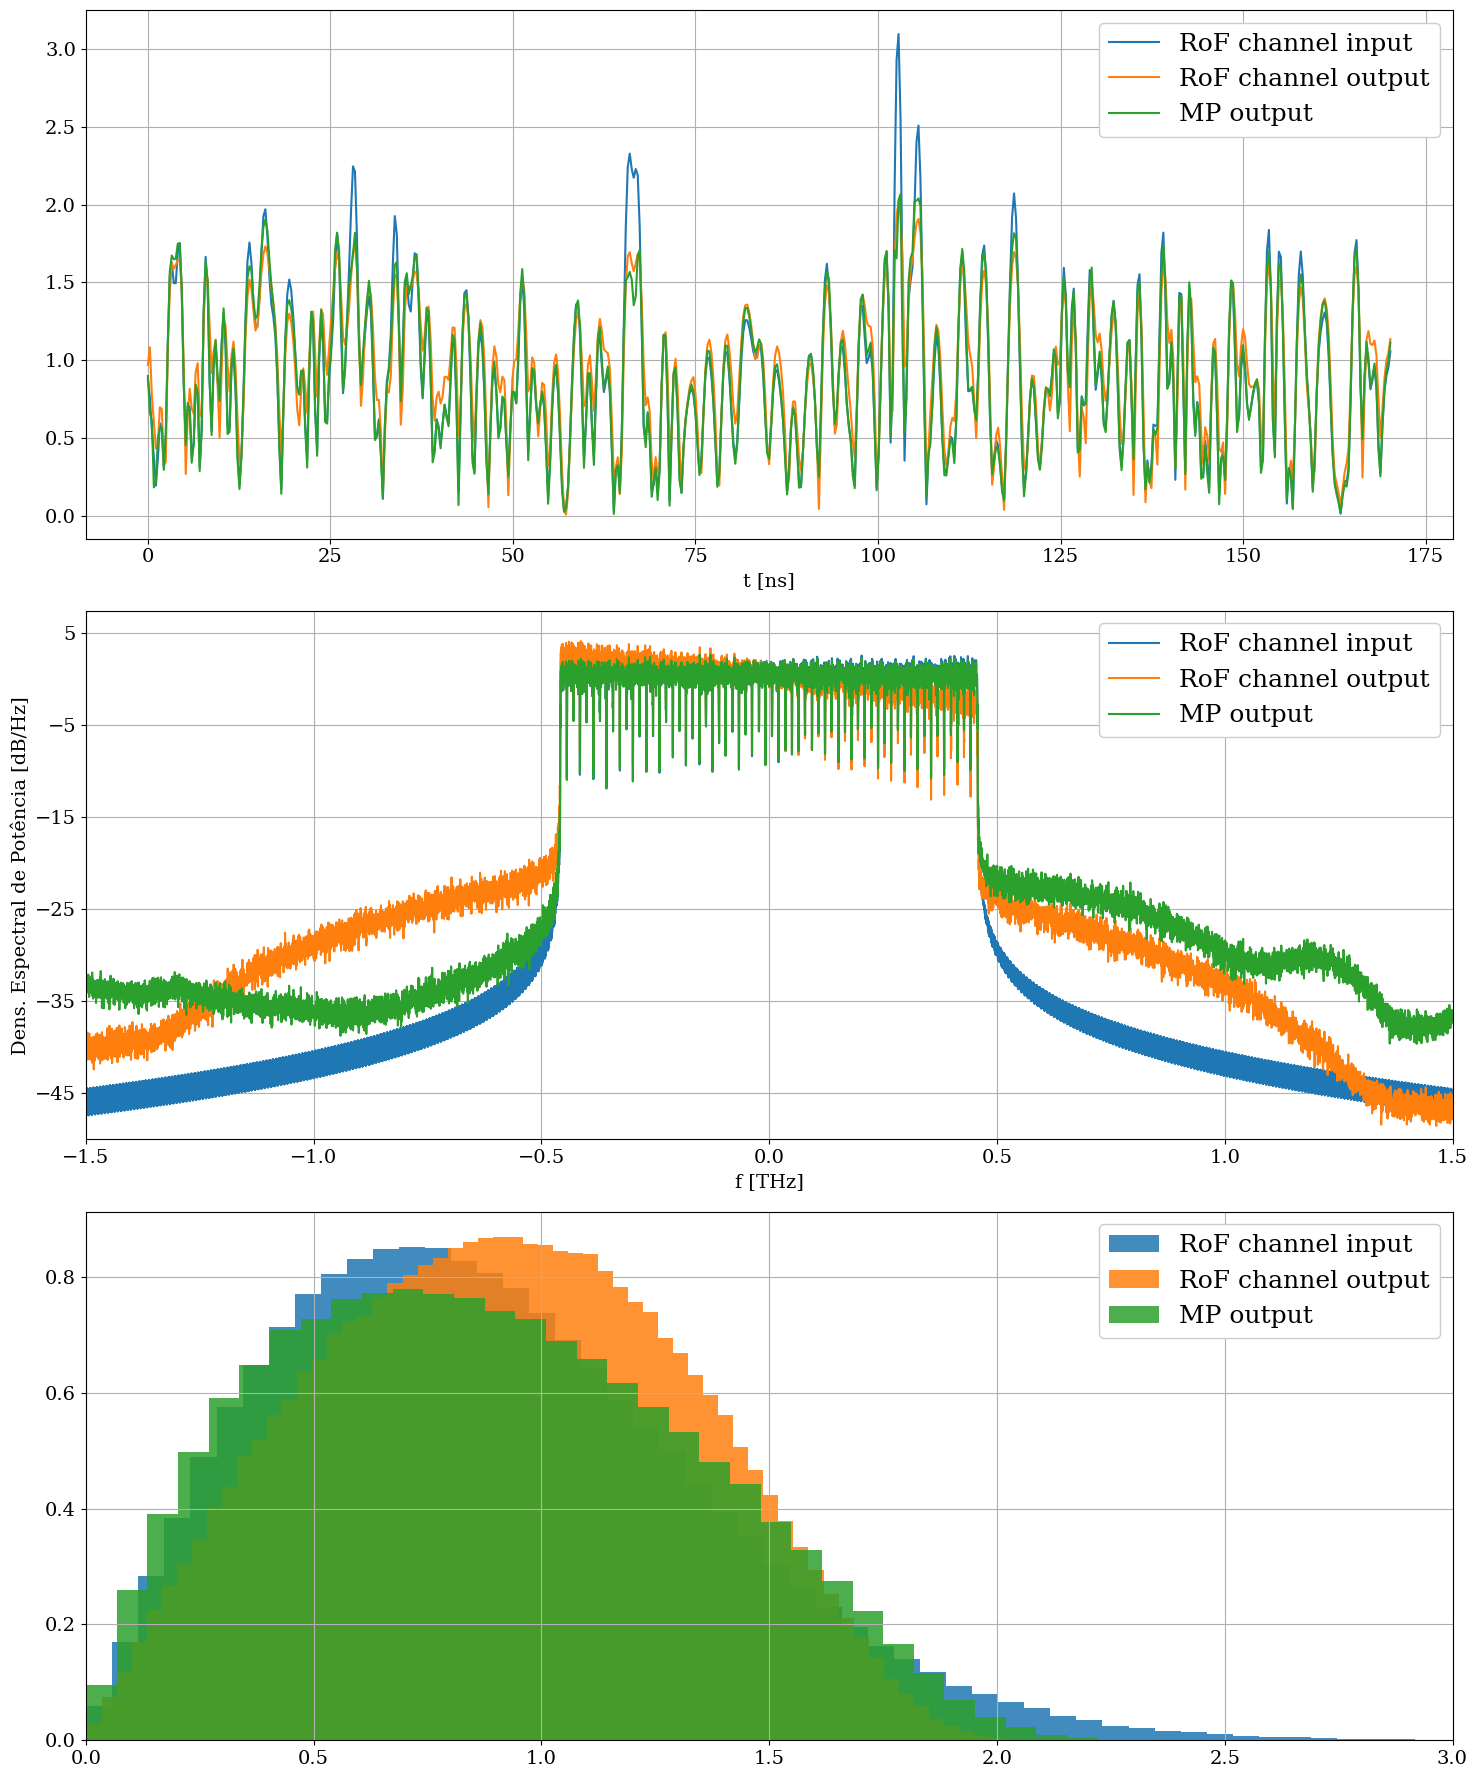

In [72]:
print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigRef)**2)):.3f} dB")

indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), label = "RoF channel input")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]), label = "RoF channel output")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), label = "MP output")
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
#axs[0].set_ylim(0, 3)
axs[0].grid()

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel input")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel output")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "MP output")
axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

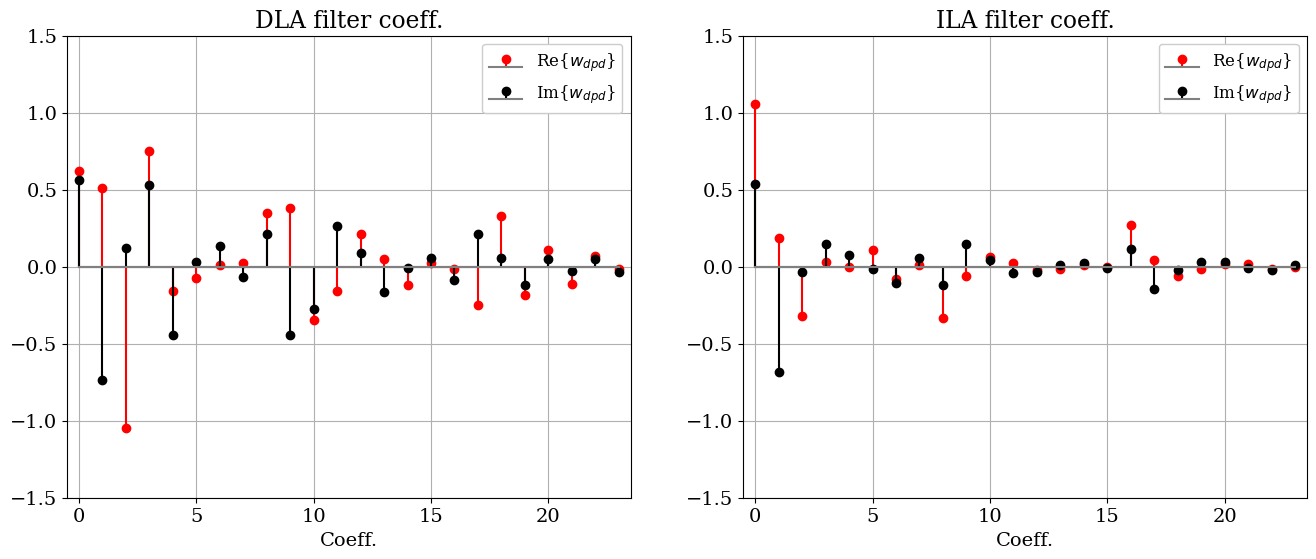

In [73]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

markerline, stemlines, baseline = axs[0].stem(w_dla.real, linefmt = 'red',   markerfmt = 'o', basefmt = "gray", label = r"Re{$w_{dpd}$}")
markerline, stemlines, baseline = axs[0].stem(w_dla.imag, linefmt = 'black',   markerfmt = 'o', basefmt = "gray", label = r"Im{$w_{dpd}$}")

markerline, stemlines, baseline = axs[1].stem(w_ila.real, linefmt = 'red',   markerfmt = 'o', basefmt = "gray", label = r"Re{$w_{dpd}$}")
markerline, stemlines, baseline = axs[1].stem(w_ila.imag, linefmt = 'black',   markerfmt = 'o', basefmt = "gray", label = r"Im{$w_{dpd}$}")

axs[0].set_title("DLA filter coeff.")
axs[0].set_xlim(-0.5, P*M - 0.5)
axs[0].set_ylim(-1.5, 1.5)
axs[0].set_xlabel("Coeff.")
axs[0].legend(framealpha = 1, loc = "upper right", fontsize = 12)
axs[0].grid()

axs[1].set_title("ILA filter coeff.")
axs[1].set_xlim(-0.5, P*M - 0.5)
axs[1].set_ylim(-1.5, 1.5)
axs[1].set_xlabel("Coeff.")
axs[1].legend(framealpha = 1, loc = "upper right", fontsize = 12)
axs[1].grid()

### 6 - DPD Test

In [74]:
# Parâmetros da modulação
modOrder = 64                          # Ordem da modulação
modType  = 'qam'                       # Tipo de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 64                               # Amostras por símbolo
SpS_mp = 4

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                  # Tam. da FFT
paramOFDM.Np   = 64                    # Núm. de subportadoras piloto
paramOFDM.G    = 32                    # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS_mp
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft-1, paramOFDM.Np, dtype=np.int64) # Pilot subcarriers
Ns = paramOFDM.Nfft - paramOFDM.Np     # Núm. de subportadoras de informação

Rs = Rb / ( Ns/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
batchSize = 1000//(int(paramOFDM.Nfft/128))
bits = np.random.randint(2, size = batchSize * Ns * int(np.log2(modOrder) ) )

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [75]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

sigTx_DPD_ILA = MP_filter(sigTx, np.conj(w_ila).reshape((P, M)))
sigTx_DPD_DLA = MP_filter(sigTx, np.conj(w_dla).reshape((P, M)))

In [76]:
numtaps = 4096
h_dpd = firwin(numtaps, 2*Rs, fs = Fs)

# ILA
sigTx_DPD_ILA = upsample(sigTx_DPD_ILA.ravel(), SpS//SpS_mp).reshape(-1,) 
sigTx_DPD_ILA = firFilter(h_dpd, sigTx_DPD_ILA)

# DLA
sigTx_DPD_DLA = upsample(sigTx_DPD_DLA.ravel(), SpS//SpS_mp).reshape(-1,) 
sigTx_DPD_DLA = firFilter(h_dpd, sigTx_DPD_DLA)

In [77]:
t = np.arange(0, sigTx_DPD_DLA.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

#### 6.1 Sinal RF

In [78]:
sigTx_RF_ILA = np.real( sigTx_DPD_ILA * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_ILA = np.sqrt(dBm2W(paramRF.Pin_RF))*pnorm(sigTx_RF_ILA)

sigTx_RF_DLA = np.real( sigTx_DPD_DLA * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_DLA = np.sqrt(dBm2W(paramRF.Pin_RF))*pnorm(sigTx_RF_DLA)

#### 6.2 Sinal óptico

In [79]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF_ILA.size)
sigTxo_ILA = mzm(Ai, sigTx_RF_ILA, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo_ILA = np.sqrt(signal_power(sigTxo_ILA))*pnorm(firFilter(hopt_tx, sigTxo_ILA))

sigRxo_ILA = linearFiberChannel(sigTxo_ILA, paramChannel)

In [80]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF_DLA.size)
sigTxo_DLA = mzm(Ai, sigTx_RF_DLA, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo_DLA = np.sqrt(signal_power(sigTxo_DLA))*pnorm(firFilter(hopt_tx, sigTxo_DLA))

sigRxo_DLA = linearFiberChannel(sigTxo_DLA, paramChannel)

#### 6.3 Sinal elétrico (fotocorrente)

In [81]:
I_Rx_ILA = photodiode(sigRxo_ILA, paramPD)
I_Rx_ILA = pnorm(I_Rx_ILA)
I_Rx_ILA -= I_Rx_ILA.mean()

In [82]:
I_Rx_DLA = photodiode(sigRxo_DLA, paramPD)
I_Rx_DLA = pnorm(I_Rx_DLA)
I_Rx_DLA -= I_Rx_DLA.mean()

#### 6.4 Sinal elétrico pós-FPF

In [83]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF_ILA = firFilter(hbp_RF, I_Rx_ILA)
I_RF_DLA = firFilter(hbp_RF, I_Rx_DLA)

#### 6.5 Sinal elétrico pós-PA

In [84]:
sigRx_ILA = hilbert(I_RF_ILA)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx_ILA = np.sqrt(dBm2W(paramRF.Pin_PA))*pnorm(sigRx_ILA)
sigRx_ILA = powerAmplifier(sigRx_ILA)

sigRx_PA_DPD_ILA = sigRx_ILA.copy()

numtaps = 4096
hlp = firwin(numtaps, Rs/1.5, fs = Fs)
sigRx_ILA = firFilter(hlp, sigRx_ILA)

delay = finddelay(sigRx_ILA, sigTx_DPD_ILA)
sigRx_ILA = np.roll(sigRx_ILA, -delay)

rot = np.mean(sigTx_DPD_ILA/sigRx_ILA)
sigRx_ILA = rot/np.abs(rot)*sigRx_ILA

In [85]:
sigRx_DLA = hilbert(I_RF_DLA)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx_DLA = np.sqrt(dBm2W(paramRF.Pin_PA))*pnorm(sigRx_DLA)
sigRx_DLA = powerAmplifier(sigRx_DLA)

sigRx_PA_DPD_DLA = sigRx_DLA.copy()

numtaps = 4096
hlp = firwin(numtaps, Rs/1.5, fs = Fs)
sigRx_DLA = firFilter(hlp, sigRx_DLA)

delay = finddelay(sigRx_DLA, sigTx_DPD_DLA)
sigRx_DLA = np.roll(sigRx_DLA, -delay)

rot = np.mean(sigTx_DPD_DLA/sigRx_DLA)
sigRx_DLA = rot/np.abs(rot)*sigRx_DLA

#### Perfomance

In [86]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx_ILA, paramDec).ravel()
symbRx_DPD_ILA = demodulateOFDM(symbRx_OFDM, paramOFDM)

symbRx_OFDM = decimate(sigRx_DLA, paramDec).ravel()
symbRx_DPD_DLA = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00018 
SNR = 24.986 dB 
EVM = -24.973 dB


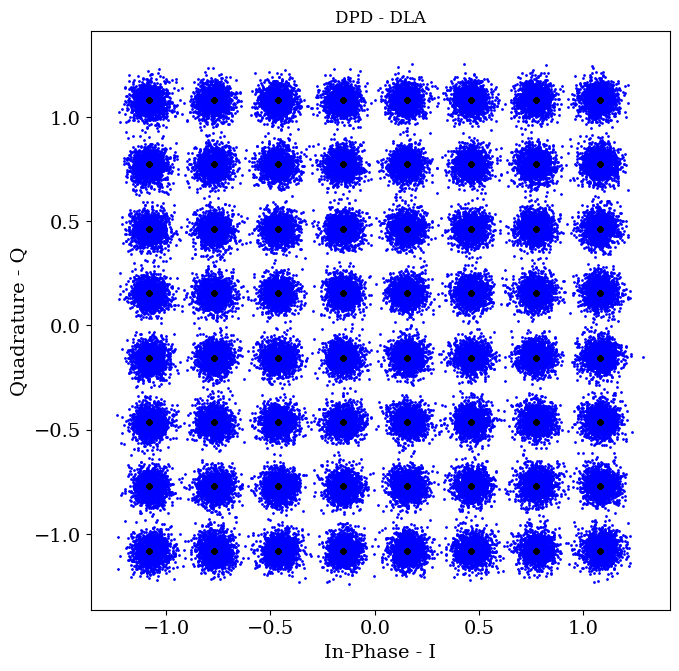

In [87]:
discard = 500
index = np.arange(discard, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD_DLA[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx_DPD_DLA, modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_DLA = pnorm(symbRx_DPD_DLA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx_DPD_DLA.real, symbRx_DPD_DLA.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_title(f"DPD - DLA", fontsize = 12)
axs.set_ylabel("Quadrature - Q")
axs.set_xlabel("In-Phase - I")
plt.axis("square")
plt.tight_layout()

BER = 0.00000 
SNR = 32.428 dB 
EVM = -32.429 dB


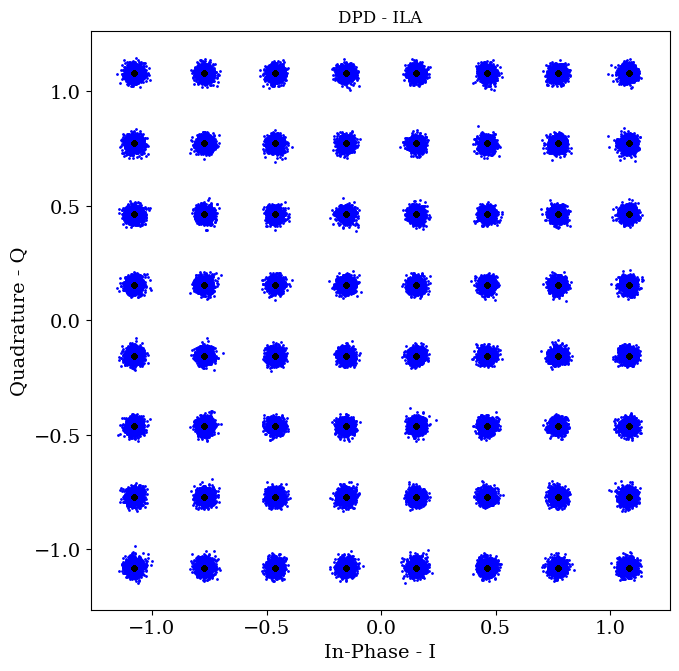

In [88]:
discard = 500
index = np.arange(discard, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD_ILA[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx_DPD_ILA, modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_ILA = pnorm(symbRx_DPD_ILA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx_DPD_ILA.real, symbRx_DPD_ILA.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_title(f"DPD - ILA", fontsize = 12)
axs.set_ylabel("Quadrature - Q")
axs.set_xlabel("In-Phase - I")
plt.axis("square")
plt.tight_layout()

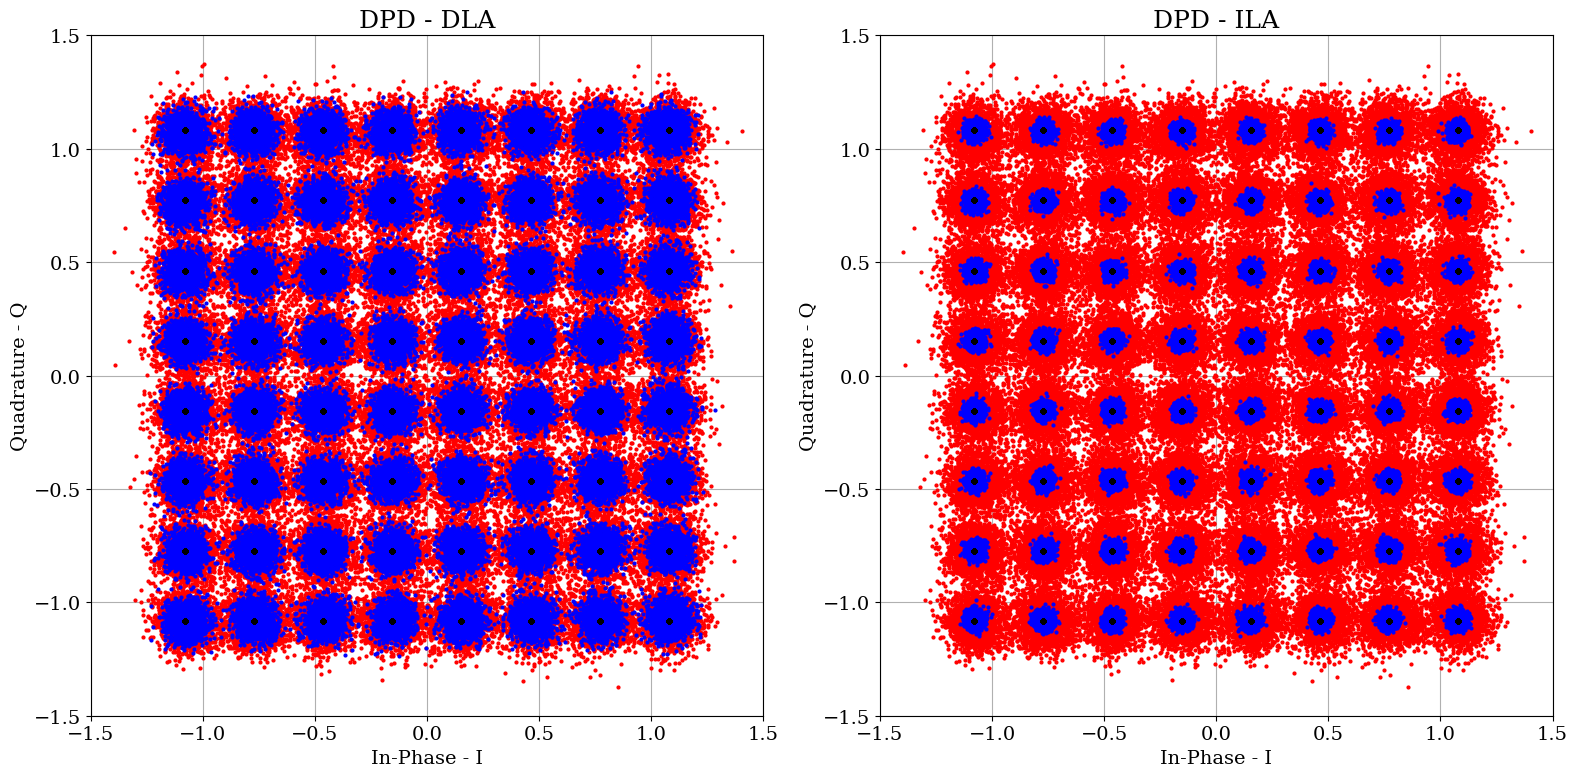

In [89]:
# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(1, 2, figsize = (16, 8))

axs[0].plot(symbRx.real, symbRx.imag, "o", color = "r", ms = 2, label = "Sem DPD")
axs[0].plot(symbRx_DPD_DLA.real, symbRx_DPD_DLA.imag, "o", color = "b", ms = 2, label = "Com DPD")
axs[0].plot(symbTx.real, symbTx.imag, "o", color = "k",  ms = 3, label = "SymbTx")
axs[0].set_title("DPD - DLA", fontsize = 18)
axs[0].set_ylabel("Quadrature - Q")
axs[0].set_xlabel("In-Phase - I")
axs[0].set_xlim(-1.5, 1.5)
axs[0].set_ylim(-1.5, 1.5)
axs[0].grid()

axs[1].plot(symbRx.real, symbRx.imag, "o", color = "r", ms = 2, label = "Sem DPD")
axs[1].plot(symbRx_DPD_ILA.real, symbRx_DPD_ILA.imag, "o", color = "b", ms = 2, label = "Com DPD")
axs[1].plot(symbTx.real, symbTx.imag, "o", color = "k",  ms = 3, label = "SymbTx")
axs[1].set_title("DPD - ILA", fontsize = 18)
axs[1].set_ylabel("Quadrature - Q")
axs[1].set_xlabel("In-Phase - I")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-1.5, 1.5)
axs[1].grid()

plt.tight_layout()

SNR improvement mean: 4.710 dB


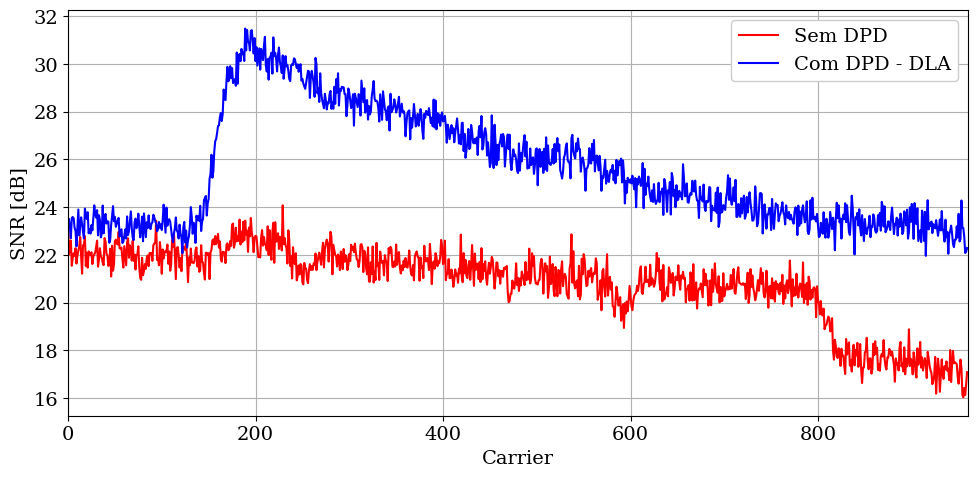

In [90]:
rx = np.reshape(symbRx_DPD_DLA, (-1, Ns))
tx = np.reshape(symbTx.copy(), (-1, Ns))

SNR_per_carrier_DLA = np.zeros(Ns)

for k in range(Ns):
    SNR_per_carrier_DLA[k] = 10*np.log10(signal_power(tx[:, k]) / signal_power(rx[:, k] - tx[:, k]))


fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(SNR_per_carrier, color = "r", label = "Sem DPD")
axs.plot(SNR_per_carrier_DLA, color = "b", label = "Com DPD - DLA")
axs.set_xlim(0, Ns)
axs.set_ylabel("SNR [dB]")
axs.set_xlabel("Carrier")
axs.legend(framealpha = 1, fontsize = 14)
axs.grid()
plt.tight_layout()

print(f"SNR improvement mean: {np.mean(SNR_per_carrier_DLA - SNR_per_carrier) :.3f} dB")

SNR improvement mean: 11.738 dB


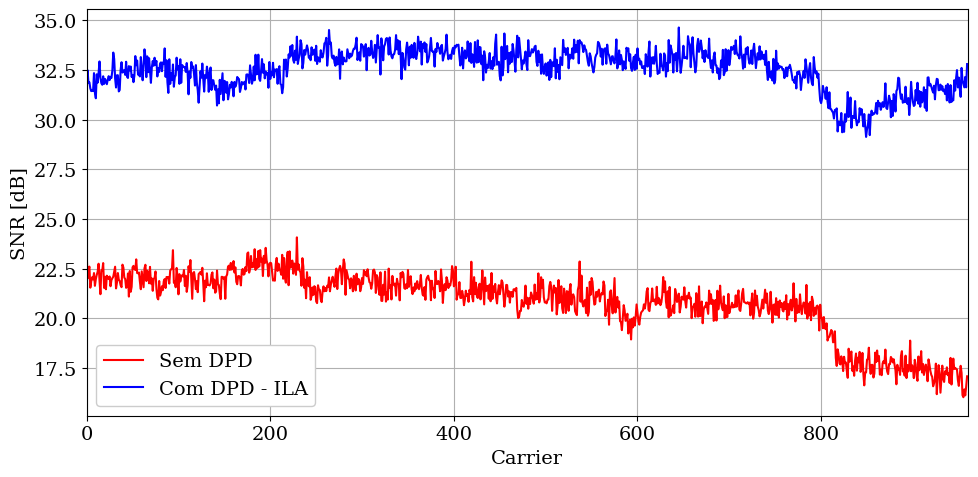

In [91]:
rx = np.reshape(symbRx_DPD_ILA, (-1, Ns))
tx = np.reshape(symbTx.copy(), (-1, Ns))

SNR_per_carrier_ILA = np.zeros(Ns)

for k in range(Ns):
    SNR_per_carrier_ILA[k] = 10*np.log10(signal_power(tx[:, k]) / signal_power(rx[:, k] - tx[:, k]))


fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(SNR_per_carrier, color = "r", label = "Sem DPD")
axs.plot(SNR_per_carrier_ILA, color = "b", label = "Com DPD - ILA")
axs.set_xlim(0, Ns)
axs.set_ylabel("SNR [dB]")
axs.set_xlabel("Carrier")
axs.legend(framealpha = 1, fontsize = 14)
axs.grid()
plt.tight_layout()

print(f"SNR improvement mean: {np.mean(SNR_per_carrier_ILA - SNR_per_carrier) :.3f} dB")

In [92]:
freq, P_sigTx            = welch(pnorm(sigTx), fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA         = welch(pnorm(sigRx_PA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_DLA = welch(pnorm(sigRx_PA_DPD_DLA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_ILA = welch(pnorm(sigRx_PA_DPD_ILA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)

SigTx - ACLR = -33.195 dB
SigRx PA w/o DPD - ACLR = -24.774 dB
SigRx PA w DPD-ILA - ACLR = -26.225 dB
SigRx PA w DPD-DLA - ACLR = -24.494 dB


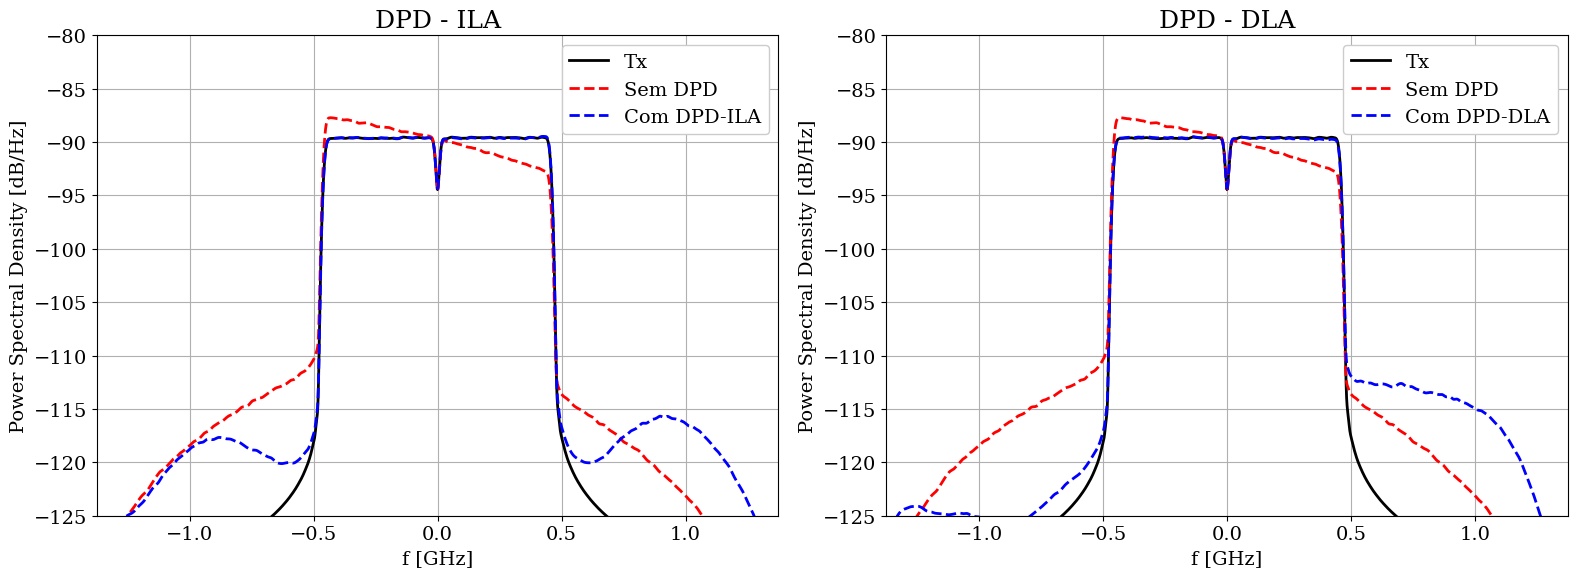

In [93]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

axs[0].plot(freq/1e9, 10*np.log10(P_sigTx), color = "k", ls = "-", lw = 2, label = "Tx")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA), color = "r", ls = "--", lw = 2, label = "Sem DPD")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_ILA), color = "b", ls = "--", lw = 2, label = r"Com DPD-ILA")
axs[0].set_title("DPD - ILA", fontsize = 18)
axs[0].set_xlim(-1.5*Rs/1e9, 1.5*Rs/1e9)
axs[0].set_ylim(-125, -80)
axs[0].set_xlabel("f [GHz]")
axs[0].set_ylabel("Power Spectral Density [dB/Hz]")
axs[0].legend(fontsize = 14, framealpha = 1)
axs[0].grid()

axs[1].plot(freq/1e9, 10*np.log10(P_sigTx), color = "k", ls = "-", lw = 2, label = "Tx")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA), color = "r", ls = "--", lw = 2, label = "Sem DPD")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_DLA), color = "b", ls = "--", lw = 2, label = r"Com DPD-DLA")
axs[1].set_title("DPD - DLA", fontsize = 18)
axs[1].set_xlim(-1.5*Rs/1e9, 1.5*Rs/1e9)
axs[1].set_ylim(-125, -80)
axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Power Spectral Density [dB/Hz]")
axs[1].legend(fontsize = 14, framealpha = 1)
axs[1].grid()

plt.tight_layout()

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-ILA - ACLR = {calcACLR(P_sigRx_PA_DPD_ILA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-DLA - ACLR = {calcACLR(P_sigRx_PA_DPD_DLA, freq, 0.5e9):.3f} dB")